# Dynamic Time Warping

In [1]:
# We'll need numpy for some mathematical operations
import numpy as np

# Librosa for audio
import librosa

# matplotlib for displaying the output
import matplotlib.pyplot as plt
%matplotlib inline

## Sequence Alignment

We want to align two audio tracks. As a little toy example,
we consider an audio track and the same audio track but
slowed-down by a certain factor.

In [ ]:
y, sr = librosa.load(librosa.util.example_audio_file())
# Let's create a slow-downed version
y_slow = librosa.effects.time_stretch(y, 0.75)

/Users/balke/Development/librosa/librosa/core/constantq.py:152: DeprecationWarning: Real-valued CQT (real=True) is deprecated in 0.4.2. Complex-valued CQT will become the default in 0.5.0. Consider using np.abs(librosa.cqt(..., real=False)) instead of real=True to maintain forward compatibility.
  DeprecationWarning)
/Users/balke/Development/librosa/librosa/core/constantq.py:152: DeprecationWarning: Real-valued CQT (real=True) is deprecated in 0.4.2. Complex-valued CQT will become the default in 0.5.0. Consider using np.abs(librosa.cqt(..., real=False)) instead of real=True to maintain forward compatibility.
  DeprecationWarning)


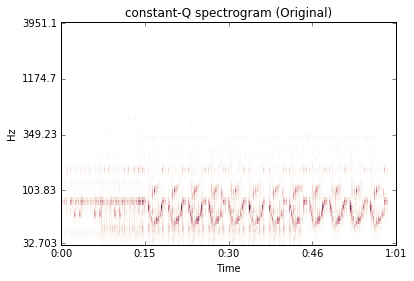

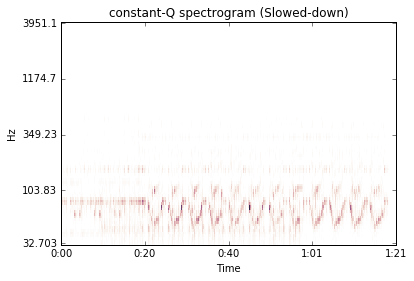

In [3]:
y_cqt = np.abs(librosa.cqt(y, sr=sr))
y_slow_cqt = np.abs(librosa.cqt(y_slow, sr=sr))

# Display the spectrogram
librosa.display.specshow(y_cqt, sr=sr, x_axis='time', y_axis='cqt_hz')

# Put a descriptive title on the plot
plt.title('constant-Q spectrogram (Original)')

plt.figure()

# Display the spectrogram
librosa.display.specshow(y_slow_cqt, sr=sr, x_axis='time', y_axis='cqt_hz')

# Put a descriptive title on the plot
plt.title('constant-Q spectrogram (Slowed-down)')

Now, we use dynamic time warping to re-align the cqt-sequences.

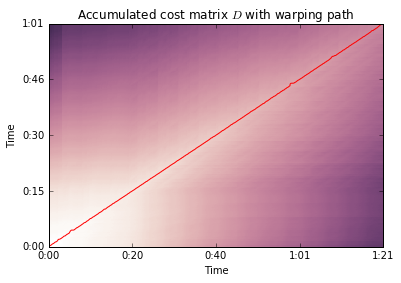

In [9]:
D, wp = librosa.dtw(y_cqt, y_slow_cqt)

# Display the accumulated cost matrix
librosa.display.specshow(D, x_axis='time', y_axis='time')

# Put a descriptive title on the plot
plt.title('Accumulated cost matrix $D$ with warping path')
x_val = [x[1] for x in wp]
y_val = [x[0] for x in wp]
plt.plot(x_val, y_val, color='r')